# Model-ready EDA: Live before lap N

Contract notebook:
- Grain: `session_key + driver_number + lap_number`.
- A row for lap `N` may only use information available before lap `N` starts, which means data up to the end of lap `N-1`.
- `*_before_lap`, `tele_prev_*`, and `loc_prev_*` are model-safe feature groups.
- `*_current_lap`, `final_position`, and `target_*` are audit/EDA columns only and must not be used as model inputs.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path('..') if Path.cwd().name == 'notebook' else Path('.')
MASTER_PATH = ROOT / 'data' / 'processed' / 'master_dataset.csv'
METADATA_PATH = ROOT / 'data' / 'metadata' / 'feature_engineering_metadata.json'
AUDIT_PATH = ROOT / 'reports' / 'data_quality' / 'master_dataset_audit.csv'

assert MASTER_PATH.exists(), f'Missing {MASTER_PATH}. Run feature engineering first.'
df = pd.read_csv(MASTER_PATH, low_memory=False)
metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8')) if METADATA_PATH.exists() else {}
audit = pd.read_csv(AUDIT_PATH) if AUDIT_PATH.exists() else pd.DataFrame()

print(f'Master shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print('Prediction contract:', metadata.get('prediction_contract'))
print('Metadata model-safe features:', len(metadata.get('model_feature_columns', [])))

Master shape: 82,535 rows x 112 columns
Prediction contract: live_before_lap_n
Metadata model-safe features: 69


## 1. Dataset Contract And Quality Gates

This section acts as the main quality gate. If any critical check fails here, the final dataset should not be used as a model-ready artifact.


In [2]:
KEY = ['session_key', 'driver_number', 'lap_number']
blocked_leakage = {
    'final_position', 'target_win', 'target_podium', 'target_top10',
    'pit_stop_count_current_lap', 'pit_duration_sum_current_lap', 'pit_duration_mean_current_lap',
    'stop_duration_mean_current_lap', 'lane_duration_mean_current_lap', 'is_pit_current_lap',
    'race_control_events_current_lap', 'yellow_flag_events_current_lap',
    'green_flag_events_current_lap', 'yellow_flag_active_current_lap',
}
model_features = set(metadata.get('model_feature_columns', []))

quality = pd.DataFrame({
    'check': [
        'rows', 'columns', 'duplicate grain rows', 'prediction contract',
        'model feature count', 'blocked leakage in model features',
    ],
    'value': [
        len(df), df.shape[1], int(df.duplicated(KEY).sum()), metadata.get('prediction_contract'),
        len(model_features), sorted(blocked_leakage & model_features),
    ],
    'expected': [
        'same as cleaned laps', '>= 100', '0', 'live_before_lap_n', '> 0', '[]',
    ],
})
display(quality)

assert df.duplicated(KEY).sum() == 0
assert metadata.get('prediction_contract') == 'live_before_lap_n'
assert model_features
assert not (blocked_leakage & model_features)

,check,value,expected
0,rows,82535,same as cleaned laps
1,columns,112,>= 100
2,duplicate grain rows,0,0
3,prediction contract,live_before_lap_n,live_before_lap_n
4,model feature count,69,> 0
5,blocked leakage in model features,[],[]


In [3]:
if not audit.empty:
    display(audit)
else:
    print('No audit CSV found. Run the master dataset audit step first for a saved report.')

,check,status,value,expected,severity
0,master_rows,pass,82535,equals cleaned laps 82535,info
1,master_columns,pass,112,>= 100 after endpoint feature expansion,info
2,duplicate_grain_rows,pass,0,0,info
3,expected_feature_columns,pass,all present,all expected columns present,info
4,model_feature_leakage_blocklist,pass,none,no labels/current-lap diagnostics in model_fea...,info
5,metadata_model_features_present,pass,69,>0,info
6,metadata_feature_list_matches_code,pass,"metadata=69, code=69",same model-safe feature set,info
7,prediction_contract,pass,live_before_lap_n,live_before_lap_n,info
8,coverage_targets,pass,100.00% rows with any value; avg missing 0.89%,>0 rows covered,info
9,coverage_pit_before,pass,100.00% rows with any value; avg missing 0.00%,>0 rows covered,info


## 2. Coverage And Missingness By Feature Group

The `tele_prev_*` and `loc_prev_*` groups are often below 100% coverage because telemetry and location availability depends on the FastF1 session data. This is not automatically an error, but the coverage must be visible before the dataset is used downstream.


In [4]:
def existing(cols):
    return [c for c in cols if c in df.columns]

groups = {
    'target/outcome': existing(['final_position', 'target_win', 'target_podium', 'target_top10']),
    'pace rolling': [c for c in df.columns if c.startswith('rolling_')] + existing(['lap_delta_prev', 'laps_to_go', 'race_completion_pct']),
    'tyre/stint': existing(['compound', 'current_tyre_age', 'compound_cliff', 'laps_until_cliff', 'is_past_cliff', 'has_stint_match']),
    'weather': existing(['air_temperature', 'track_temperature', 'humidity', 'rainfall', 'wind_speed', 'track_temp_evolution']),
    'pit before lap': [c for c in df.columns if c.startswith('pit_') and 'before_lap' in c] + existing(['was_pit_previous_lap', 'laps_since_last_pit']),
    'pit current diagnostic': [c for c in df.columns if c.startswith('pit_') and c.endswith('_current_lap')],
    'race control before lap': [c for c in df.columns if c.startswith(('race_control_', 'yellow_flag_', 'green_flag_')) and 'before_lap' in c] + existing(['yellow_flag_previous_lap']),
    'race control current diagnostic': [c for c in df.columns if c.startswith(('race_control_', 'yellow_flag_', 'green_flag_')) and c.endswith('_current_lap')],
    'overtakes': [c for c in df.columns if c.startswith(('overtakes_', 'net_overtakes_'))],
    'telemetry previous lap': [c for c in df.columns if c.startswith('tele_prev_')],
    'location previous lap': [c for c in df.columns if c.startswith('loc_prev_')],
}

coverage_rows = []
for group, cols in groups.items():
    if not cols:
        coverage_rows.append({'group': group, 'columns': 0, 'row_coverage_any': np.nan, 'avg_missing': np.nan})
        continue
    coverage_rows.append({
        'group': group,
        'columns': len(cols),
        'row_coverage_any': df[cols].notna().any(axis=1).mean(),
        'avg_missing': df[cols].isna().mean().mean(),
    })
coverage = pd.DataFrame(coverage_rows).sort_values('row_coverage_any')
display(coverage.style.format({'row_coverage_any': '{:.2%}', 'avg_missing': '{:.2%}'}))

,group,columns,row_coverage_any,avg_missing
10,location previous lap,12,71.24%,28.76%
9,telemetry previous lap,13,71.24%,28.76%
0,target/outcome,4,100.00%,0.89%
1,pace rolling,12,100.00%,3.57%
4,pit before lap,4,100.00%,9.39%
5,pit current diagnostic,3,100.00%,0.00%
2,tyre/stint,6,100.00%,0.26%
3,weather,6,100.00%,0.00%
7,race control current diagnostic,4,100.00%,0.00%
6,race control before lap,4,100.00%,0.00%


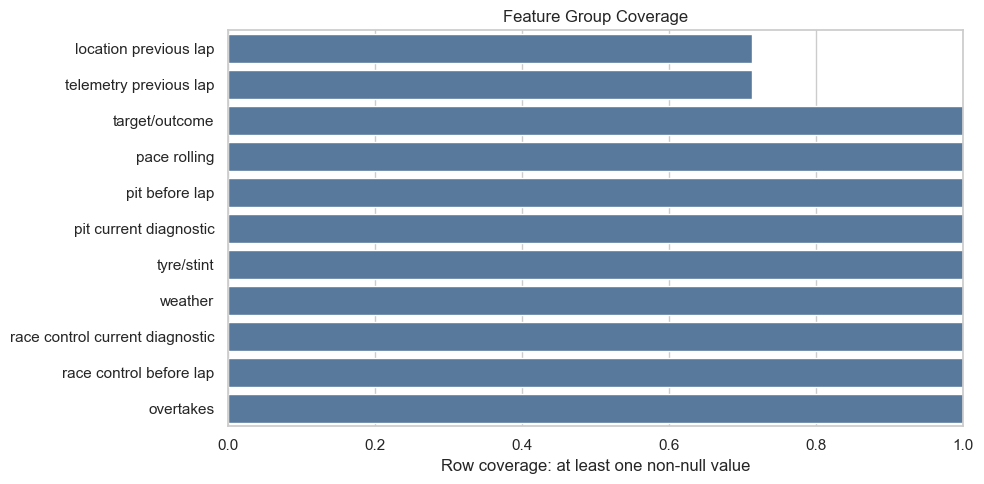

In [5]:
plot_cov = coverage.dropna(subset=['row_coverage_any']).copy()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_cov, y='group', x='row_coverage_any', ax=ax, color='#4C78A8')
ax.set_xlim(0, 1)
ax.set_xlabel('Row coverage: at least one non-null value')
ax.set_ylabel('')
ax.set_title('Feature Group Coverage')
plt.tight_layout()
plt.show()

## 3. Target Distribution And Race Progress

The main supervised-learning target is win-rate prediction, so class imbalance is one of the first things to inspect. The race-progress plots also show how labels are repeated across laps for the same driver-session.


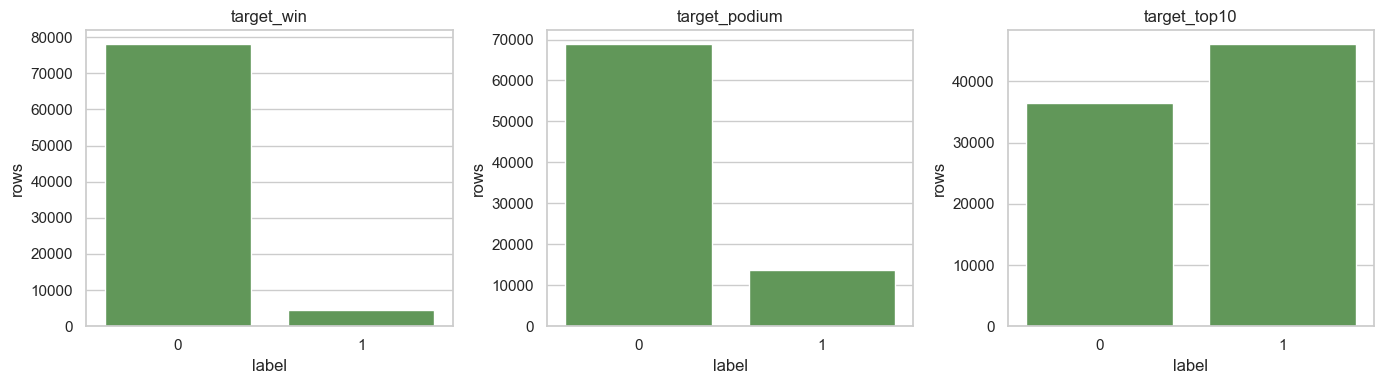

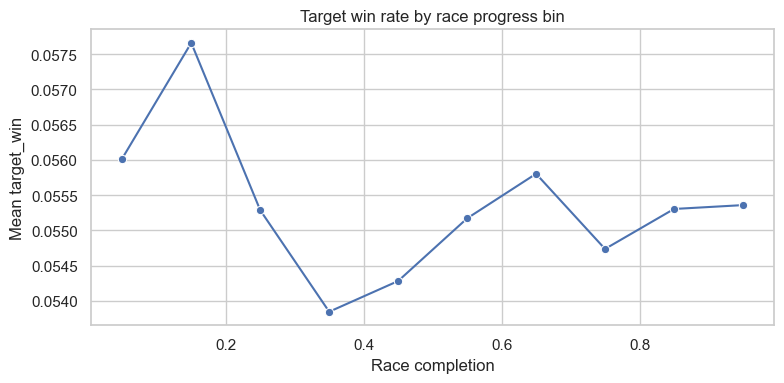

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, target in zip(axes, ['target_win', 'target_podium', 'target_top10']):
    if target not in df.columns:
        ax.axis('off')
        continue
    counts = df[target].value_counts(dropna=False).sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color='#59A14F')
    ax.set_title(target)
    ax.set_xlabel('label')
    ax.set_ylabel('rows')
plt.tight_layout()
plt.show()

if {'race_completion_pct', 'target_win'}.issubset(df.columns):
    tmp = df.dropna(subset=['race_completion_pct', 'target_win']).copy()
    tmp['progress_bin'] = pd.cut(tmp['race_completion_pct'], bins=np.linspace(0, 1, 11), include_lowest=True)
    progress = tmp.groupby('progress_bin', observed=True)['target_win'].mean().reset_index()
    progress['progress_mid'] = progress['progress_bin'].apply(lambda x: x.mid)
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.lineplot(data=progress, x='progress_mid', y='target_win', marker='o', ax=ax)
    ax.set_title('Target win rate by race progress bin')
    ax.set_xlabel('Race completion')
    ax.set_ylabel('Mean target_win')
    plt.tight_layout()
    plt.show()

## 4. Pace And Rolling Features

Rolling features are shifted before aggregation, so a row for lap `N` only receives historical pace information. This is the core feature group for the live prediction setup.


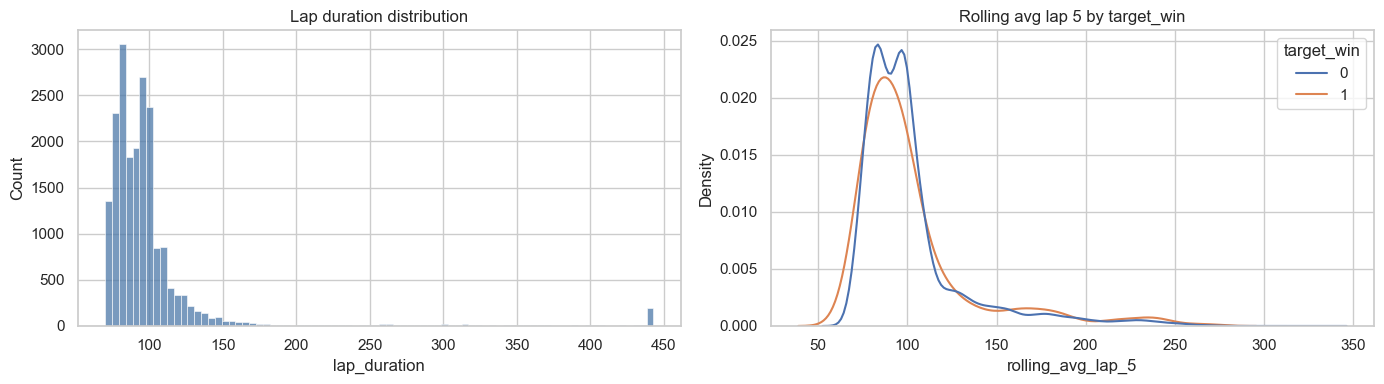

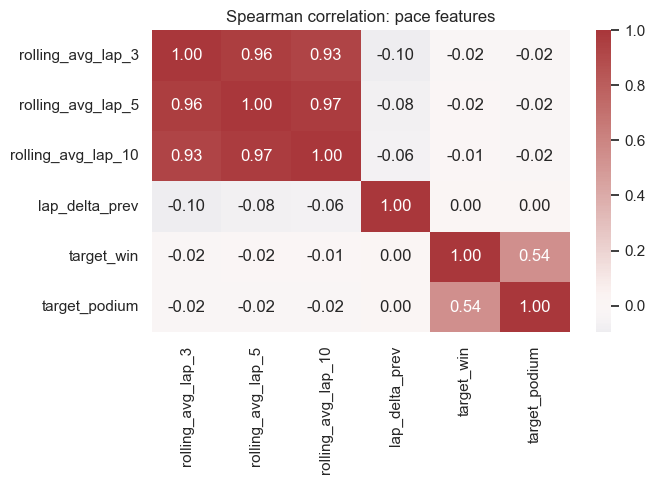

In [7]:
pace_cols = existing(['lap_duration', 'rolling_avg_lap_3', 'rolling_avg_lap_5', 'rolling_avg_lap_10', 'lap_delta_prev'])
plot_df = df[pace_cols + existing(['target_win'])].sample(min(len(df), 20000), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if 'lap_duration' in plot_df.columns:
    sns.histplot(plot_df['lap_duration'].dropna(), bins=80, ax=axes[0], color='#4C78A8')
    axes[0].set_title('Lap duration distribution')
if {'rolling_avg_lap_5', 'target_win'}.issubset(plot_df.columns):
    sns.kdeplot(data=plot_df.dropna(subset=['rolling_avg_lap_5', 'target_win']), x='rolling_avg_lap_5', hue='target_win', common_norm=False, ax=axes[1])
    axes[1].set_title('Rolling avg lap 5 by target_win')
plt.tight_layout()
plt.show()

corr_cols = [c for c in pace_cols if c != 'lap_duration'] + existing(['target_win', 'target_podium'])
if len(corr_cols) >= 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(df[corr_cols].corr(numeric_only=True, method='spearman'), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
    ax.set_title('Spearman correlation: pace features')
    plt.tight_layout()
    plt.show()

## 5. Tyre And Stint Dynamics

Tyre cliff values are learned with a hybrid approach: observed data is used, but domain bounds prevent noisy early-stint observations from dominating the result. The plots below inspect tyre age, compound behavior, and their relationship with pace.


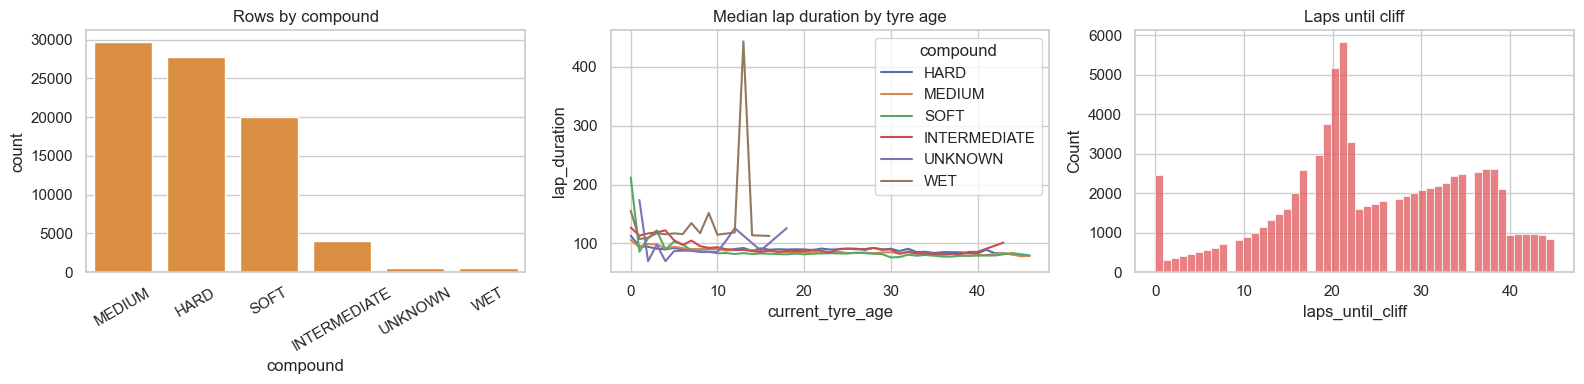

Tyre cliffs used: {'SOFT': 22, 'MEDIUM': 39, 'HARD': 45, 'INTERMEDIATE': 22, 'WET': 15, 'UNKNOWN': 24}


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
if 'compound' in df.columns:
    order = df['compound'].value_counts().index
    sns.countplot(data=df, x='compound', order=order, ax=axes[0], color='#F28E2B')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].set_title('Rows by compound')
if {'current_tyre_age', 'lap_duration', 'compound'}.issubset(df.columns):
    sample = df.dropna(subset=['current_tyre_age', 'lap_duration']).sample(min(len(df.dropna(subset=['current_tyre_age', 'lap_duration'])), 25000), random_state=42)
    sns.lineplot(data=sample, x='current_tyre_age', y='lap_duration', hue='compound', estimator='median', errorbar=None, ax=axes[1])
    axes[1].set_title('Median lap duration by tyre age')
if 'laps_until_cliff' in df.columns:
    sns.histplot(df['laps_until_cliff'].dropna(), bins=50, ax=axes[2], color='#E15759')
    axes[2].set_title('Laps until cliff')
plt.tight_layout()
plt.show()

print('Tyre cliffs used:', metadata.get('tyre_cliffs_used'))

## 6. Weather And Track Evolution

Weather is joined with a backward as-of merge and a tolerance window, which prevents the feature table from using future weather observations. This group is usually well covered because weather is a session-level time series.


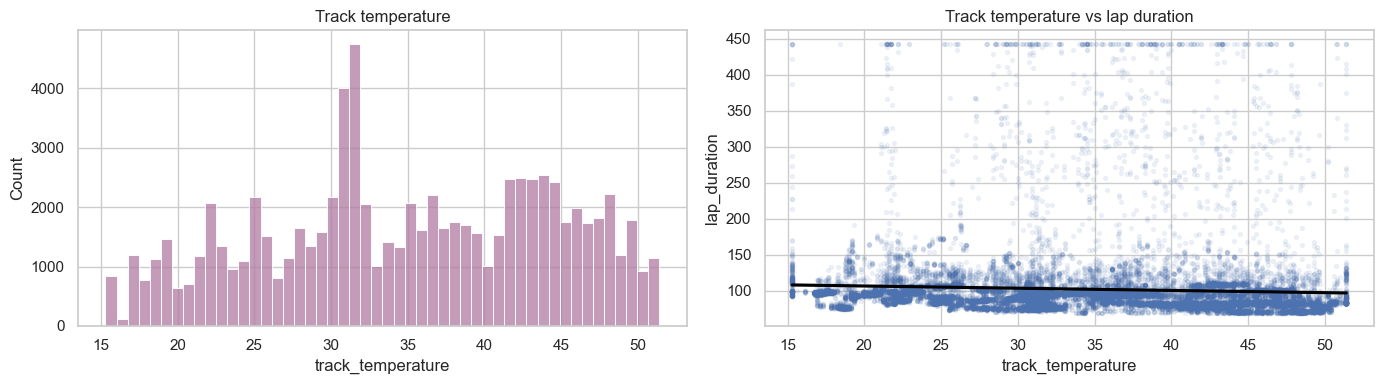

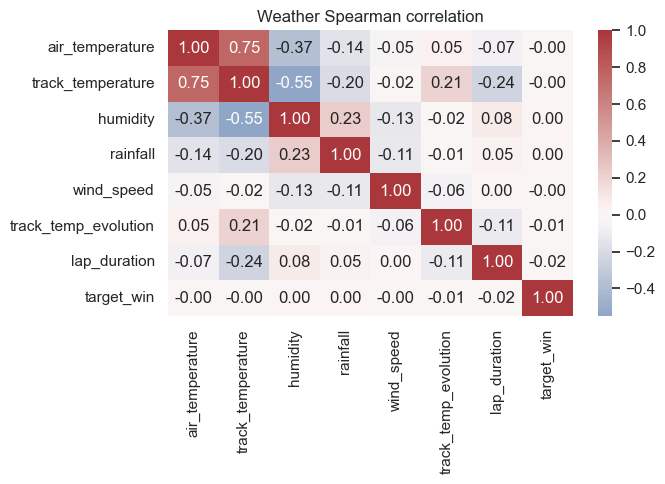

In [9]:
weather_cols = existing(['air_temperature', 'track_temperature', 'humidity', 'rainfall', 'wind_speed', 'track_temp_evolution'])
if weather_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df['track_temperature'].dropna(), bins=50, ax=axes[0], color='#B07AA1') if 'track_temperature' in df.columns else axes[0].axis('off')
    axes[0].set_title('Track temperature')
    if {'track_temperature', 'lap_duration'}.issubset(df.columns):
        sample = df.dropna(subset=['track_temperature', 'lap_duration']).sample(min(25000, df.dropna(subset=['track_temperature', 'lap_duration']).shape[0]), random_state=42)
        sns.regplot(data=sample, x='track_temperature', y='lap_duration', scatter_kws={'alpha':0.08, 's':8}, line_kws={'color':'black'}, ax=axes[1])
        axes[1].set_title('Track temperature vs lap duration')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(df[weather_cols + existing(['lap_duration', 'target_win'])].corr(numeric_only=True, method='spearman'), cmap='vlag', center=0, annot=True, fmt='.2f', ax=ax)
    ax.set_title('Weather Spearman correlation')
    plt.tight_layout()
    plt.show()

## 7. Pit Strategy And Race Control

Model-safe columns use `before_lap`. Current-lap columns remain in the dataset only for diagnostic plots, so we can inspect what happens on pit or safety-car laps without training on current/future information.


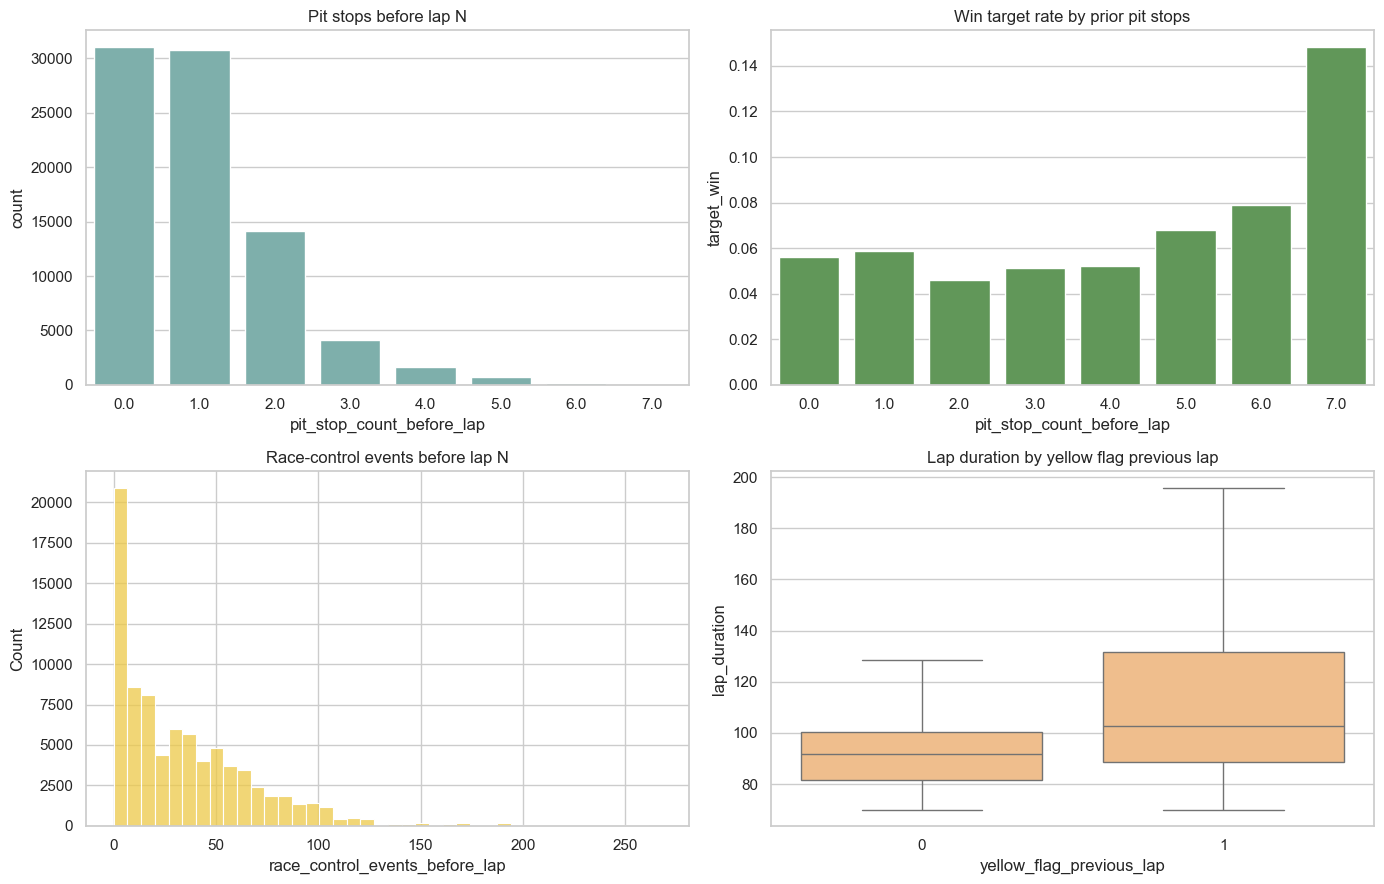

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
if 'pit_stop_count_before_lap' in df.columns:
    sns.countplot(data=df, x='pit_stop_count_before_lap', ax=axes[0,0], color='#76B7B2')
    axes[0,0].set_title('Pit stops before lap N')
if {'pit_stop_count_before_lap', 'target_win'}.issubset(df.columns):
    pit_win = df.groupby('pit_stop_count_before_lap')['target_win'].mean().reset_index()
    sns.barplot(data=pit_win, x='pit_stop_count_before_lap', y='target_win', ax=axes[0,1], color='#59A14F')
    axes[0,1].set_title('Win target rate by prior pit stops')
if 'race_control_events_before_lap' in df.columns:
    sns.histplot(df['race_control_events_before_lap'], bins=40, ax=axes[1,0], color='#EDC948')
    axes[1,0].set_title('Race-control events before lap N')
if {'yellow_flag_previous_lap', 'lap_duration'}.issubset(df.columns):
    sns.boxplot(data=df, x='yellow_flag_previous_lap', y='lap_duration', ax=axes[1,1], color='#FFBE7D', showfliers=False)
    axes[1,1].set_title('Lap duration by yellow flag previous lap')
plt.tight_layout()
plt.show()

## 8. Telemetry And Location Previous-lap Signals

The `tele_prev_*` and `loc_prev_*` columns are shifted by one lap. They are information-rich feature groups, but their coverage can be lower because they depend on telemetry/location availability.


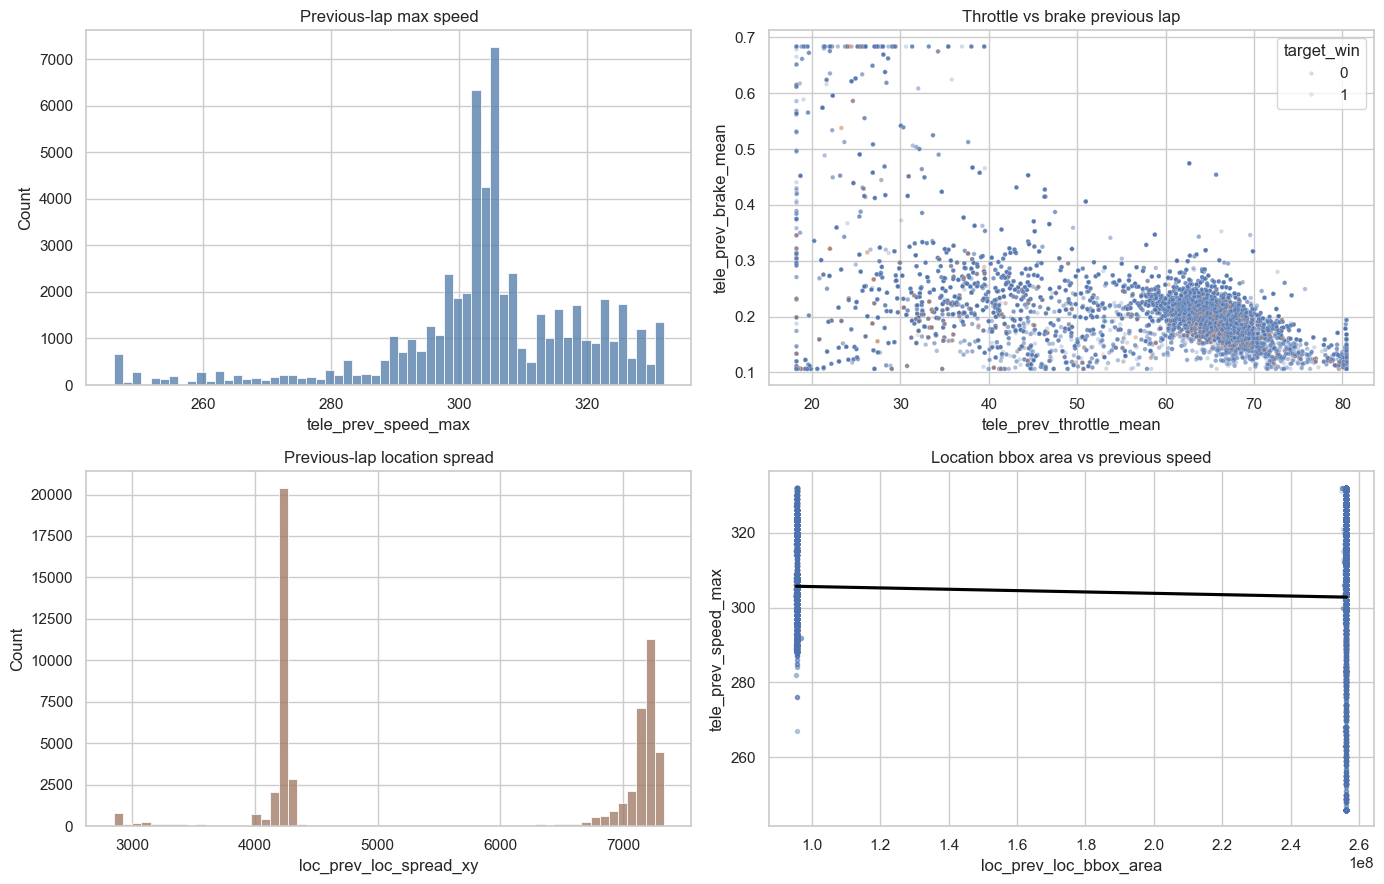

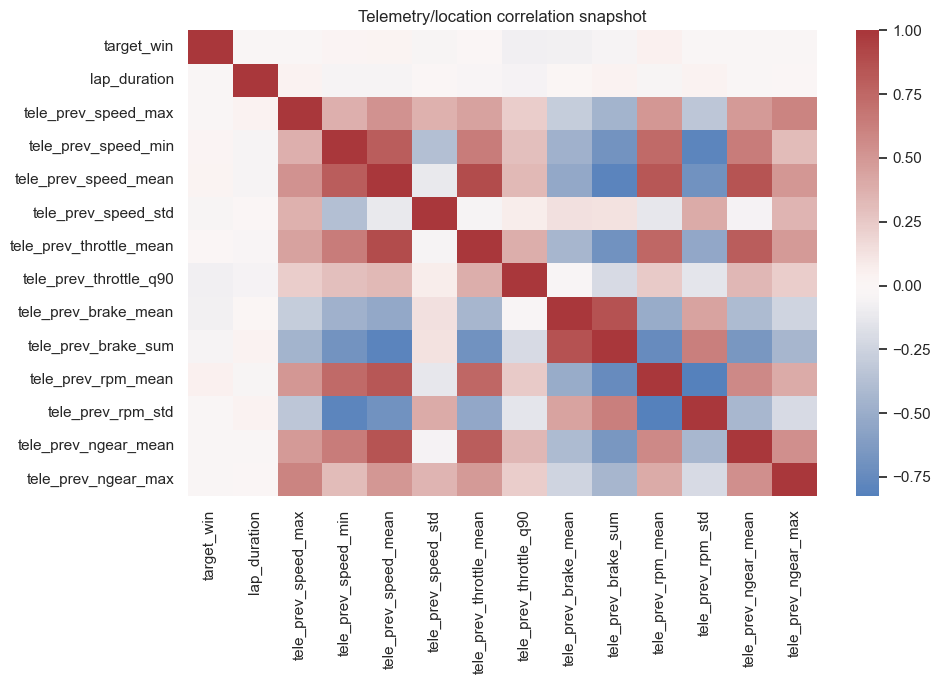

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
if 'tele_prev_speed_max' in df.columns:
    sns.histplot(df['tele_prev_speed_max'].dropna(), bins=60, ax=axes[0,0], color='#4E79A7')
    axes[0,0].set_title('Previous-lap max speed')
if {'tele_prev_throttle_mean', 'tele_prev_brake_mean'}.issubset(df.columns):
    sample = df.dropna(subset=['tele_prev_throttle_mean', 'tele_prev_brake_mean']).sample(min(25000, df.dropna(subset=['tele_prev_throttle_mean', 'tele_prev_brake_mean']).shape[0]), random_state=42)
    sns.scatterplot(data=sample, x='tele_prev_throttle_mean', y='tele_prev_brake_mean', hue=sample.get('target_win'), s=10, alpha=0.25, ax=axes[0,1])
    axes[0,1].set_title('Throttle vs brake previous lap')
if 'loc_prev_loc_spread_xy' in df.columns:
    sns.histplot(df['loc_prev_loc_spread_xy'].dropna(), bins=60, ax=axes[1,0], color='#9C755F')
    axes[1,0].set_title('Previous-lap location spread')
if {'loc_prev_loc_bbox_area', 'tele_prev_speed_max'}.issubset(df.columns):
    sample = df.dropna(subset=['loc_prev_loc_bbox_area', 'tele_prev_speed_max']).sample(min(25000, df.dropna(subset=['loc_prev_loc_bbox_area', 'tele_prev_speed_max']).shape[0]), random_state=42)
    sns.regplot(data=sample, x='loc_prev_loc_bbox_area', y='tele_prev_speed_max', scatter_kws={'alpha':0.08, 's':8}, line_kws={'color':'black'}, ax=axes[1,1])
    axes[1,1].set_title('Location bbox area vs previous speed')
plt.tight_layout()
plt.show()

tele_loc_cols = [c for c in df.columns if c.startswith(('tele_prev_', 'loc_prev_'))]
selected = existing(['target_win', 'lap_duration']) + tele_loc_cols[:12]
if len(selected) >= 3:
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(df[selected].corr(numeric_only=True, method='spearman'), cmap='vlag', center=0, ax=ax)
    ax.set_title('Telemetry/location correlation snapshot')
    plt.tight_layout()
    plt.show()

## 9. Overtakes And Competitive State

Overtake features are cumulative up to the prediction moment using event timestamps. They are useful signals for race dynamics, but they should be monitored for sparse-session bias.


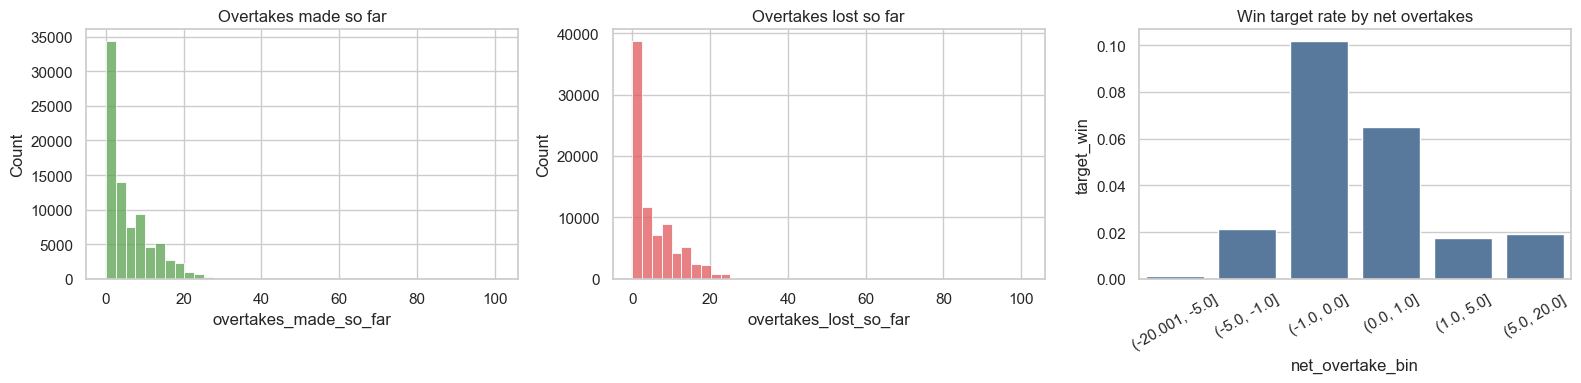

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
if 'overtakes_made_so_far' in df.columns:
    sns.histplot(df['overtakes_made_so_far'], bins=40, ax=axes[0], color='#59A14F')
    axes[0].set_title('Overtakes made so far')
if 'overtakes_lost_so_far' in df.columns:
    sns.histplot(df['overtakes_lost_so_far'], bins=40, ax=axes[1], color='#E15759')
    axes[1].set_title('Overtakes lost so far')
if {'net_overtakes_so_far', 'target_win'}.issubset(df.columns):
    tmp = df.copy()
    tmp['net_overtake_bin'] = pd.cut(tmp['net_overtakes_so_far'], bins=[-20, -5, -1, 0, 1, 5, 20], include_lowest=True)
    net = tmp.groupby('net_overtake_bin', observed=True)['target_win'].mean().reset_index()
    net['net_overtake_bin'] = net['net_overtake_bin'].astype(str)
    sns.barplot(data=net, x='net_overtake_bin', y='target_win', ax=axes[2], color='#4C78A8')
    axes[2].tick_params(axis='x', rotation=30)
    axes[2].set_title('Win target rate by net overtakes')
plt.tight_layout()
plt.show()

## 10. Model-ready Column Set

The final cell displays the model-safe numeric columns recorded in the metadata. This list should be treated as the default input feature set for a future baseline model.


In [13]:
model_feature_columns = metadata.get('model_feature_columns', [])
feature_table = pd.DataFrame({'model_feature': model_feature_columns})
display(feature_table)
print(f'Model-safe features: {len(model_feature_columns)}')
print('Targets:', [c for c in ['target_win', 'target_podium', 'target_top10'] if c in df.columns])

,model_feature
0,meeting_key
1,duration_sector_1
2,duration_sector_2
3,duration_sector_3
4,i1_speed
...,...
64,loc_prev_z_min
65,loc_prev_z_max
66,loc_prev_z_std
67,loc_prev_loc_bbox_area


Model-safe features: 69
Targets: ['target_win', 'target_podium', 'target_top10']
